(3) C4_Q15 in p. 133 (Regression)
15. This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

In [11]:
import pandas as pd
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

# Load the Boston data set
Boston = load_data('Boston')

In [13]:
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [15]:
Boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [9]:
Boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


(a) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

In [3]:
# Define the response variable
response = 'crim'

# Get the list of predictors
predictors = Boston.columns.tolist()
predictors.remove(response)  # Remove the response variable itself

# Loop through each predictor and fit a simple linear regression model
results = {}  # Store the results for each predictor
for predictor in predictors:
    # Fit the simple linear regression model
    formula = f'{response} ~ {predictor}'
    model = sm.ols(formula, data=Boston).fit()

    # Store the results
    results[predictor] = {
        'coefficient': model.params[predictor],
        'p_value': model.pvalues[predictor],
        'r_squared': model.rsquared
    }

    # Print the results
    print(f"Predictor: {predictor}")
    print(f"  Coefficient: {results[predictor]['coefficient']:.4f}")
    print(f"  P-value: {results[predictor]['p_value']:.4f}")
    print(f"  R-squared: {results[predictor]['r_squared']:.4f}")
    print("-" * 30)

Predictor: zn
  Coefficient: -0.0739
  P-value: 0.0000
  R-squared: 0.0402
------------------------------
Predictor: indus
  Coefficient: 0.5098
  P-value: 0.0000
  R-squared: 0.1653
------------------------------
Predictor: chas
  Coefficient: -1.8928
  P-value: 0.2094
  R-squared: 0.0031
------------------------------
Predictor: nox
  Coefficient: 31.2485
  P-value: 0.0000
  R-squared: 0.1772
------------------------------
Predictor: rm
  Coefficient: -2.6841
  P-value: 0.0000
  R-squared: 0.0481
------------------------------
Predictor: age
  Coefficient: 0.1078
  P-value: 0.0000
  R-squared: 0.1244
------------------------------
Predictor: dis
  Coefficient: -1.5509
  P-value: 0.0000
  R-squared: 0.1441
------------------------------
Predictor: rad
  Coefficient: 0.6179
  P-value: 0.0000
  R-squared: 0.3913
------------------------------
Predictor: tax
  Coefficient: 0.0297
  P-value: 0.0000
  R-squared: 0.3396
------------------------------
Predictor: ptratio
  Coefficient: 1.1520

In [5]:
# Identify statistically significant associations
significant_predictors = [p for p, r in results.items() if r['p_value'] < 0.05]
print("\nStatistically Significant Associations (p < 0.05):")
for predictor in significant_predictors:
    print(f"- {predictor}")


Statistically Significant Associations (p < 0.05):
- zn
- indus
- nox
- rm
- age
- dis
- rad
- tax
- ptratio
- lstat
- medv


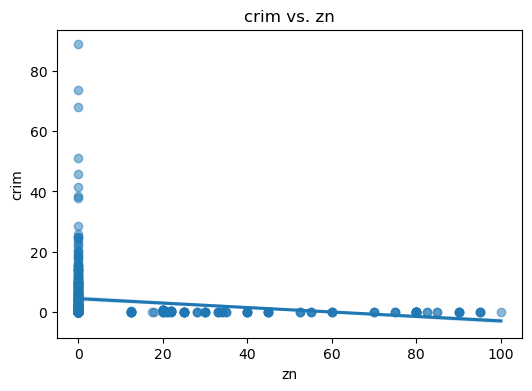

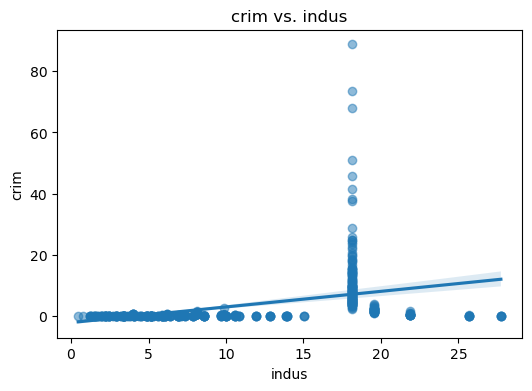

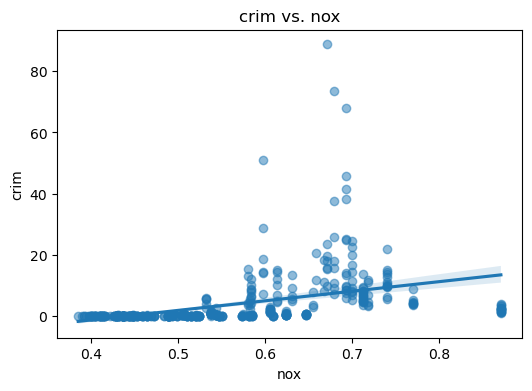

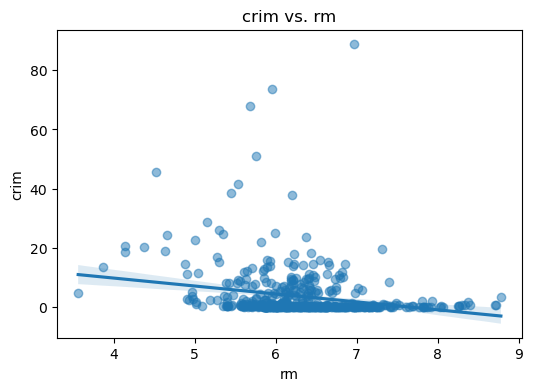

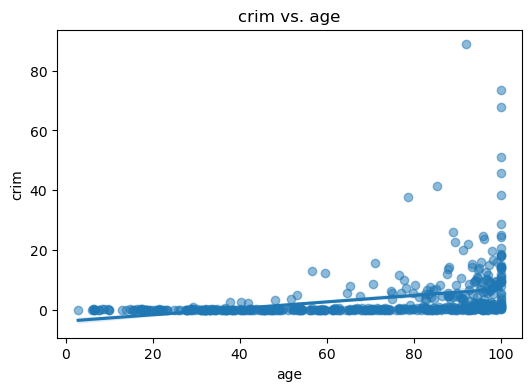

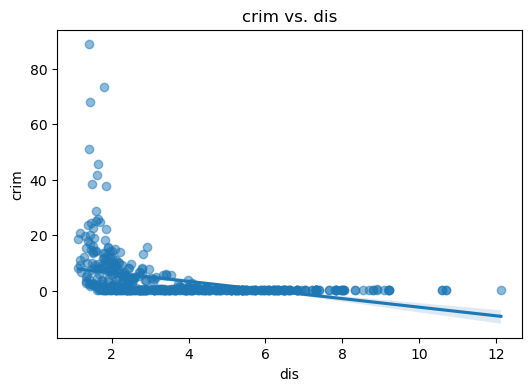

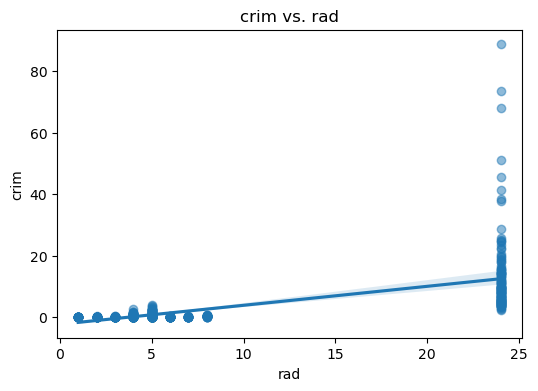

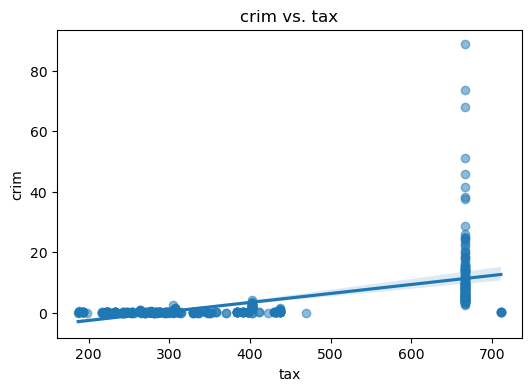

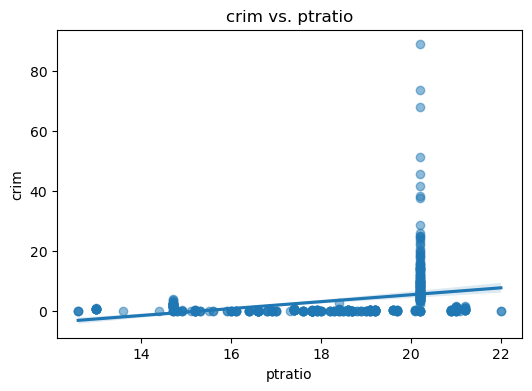

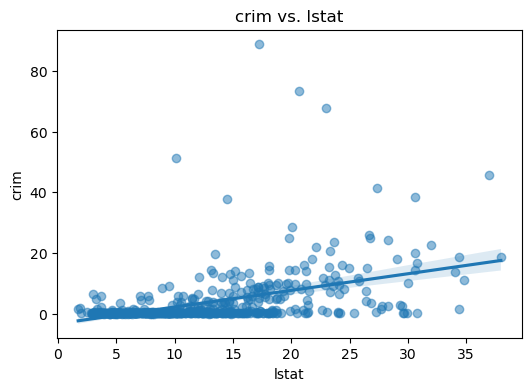

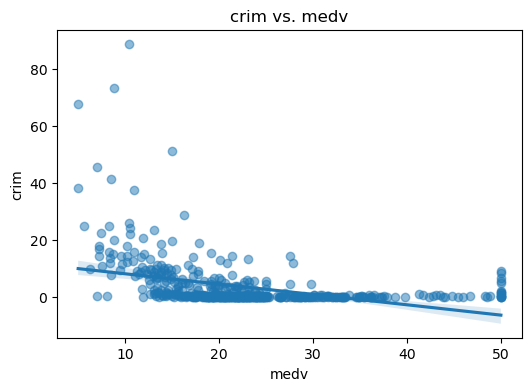

In [7]:
# Create scatter plots to back up assertions (only for significant predictors)
for predictor in significant_predictors:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=predictor, y=response, data=Boston, scatter_kws={'alpha':0.5})
    plt.title(f'{response} vs. {predictor}')
    plt.xlabel(predictor)
    plt.ylabel(response)
    plt.show()

(b) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H0 : βj = 0?

In [17]:
# Create the formula string
predictors = "+".join(Boston.columns.drop(response))  # All columns except 'crim'
formula = f"{response} ~ {predictors}"

# Fit the multiple regression model
model = sm.ols(formula, data=Boston).fit()

# Print the model summary
print(model.summary())

# Identify predictors for which we can reject the null hypothesis H0: Bj = 0
alpha = 0.05  # Significance level
reject_null = model.pvalues[model.pvalues < alpha] #Filters out insignificant features
print("\nPredictors for which we can reject H0: Bj = 0 (p < {}):".format(alpha))
for predictor, p_value in reject_null.items():
    print(f"- {predictor}: {p_value:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        12:06:48   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.7784      7.082      1.946      0.0

> 交通不方便 dis rad /自有住宅的中位數價值高 medv / 住宅用地超過 25,000平方英尺的比例低 zn >犯罪率低

(c) How do your results from (a) compare to your results from (b)? Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

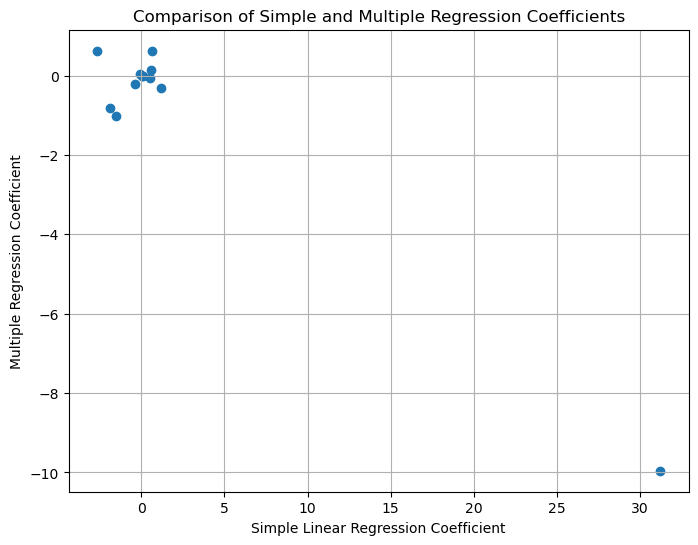

In [33]:
# --- (a) Simple Linear Regressions ---
simple_results = {}
predictors = Boston.columns.tolist()
predictors.remove(response)

for predictor in predictors:
    formula = f'{response} ~ {predictor}'
    model = sm.ols(formula, data=Boston).fit()
    simple_results[predictor] = model.params[predictor]

# --- (b) Multiple Regression ---
predictors_str = "+".join(predictors)
formula_multiple = f"{response} ~ {predictors_str}"
model_multiple = sm.ols(formula_multiple, data=Boston).fit()

# --- Create DataFrame for Plotting ---
comparison_data = pd.DataFrame({
    'simple_regression_coefficient': simple_results,
    'multiple_regression_coefficient': model_multiple.params[predictors]
})

# --- Create the Scatter Plot ---
plt.figure(figsize=(8, 6))
#for i, predictor in enumerate(predictors):
#    plt.annotate(predictor, (comparison_data['simple_regression_coefficient'][predictor], comparison_data['multiple_regression_coefficient'][predictor]), textcoords="offset points", xytext=(5,5), ha='left')

plt.scatter(comparison_data['simple_regression_coefficient'], comparison_data['multiple_regression_coefficient'])
plt.xlabel('Simple Linear Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Comparison of Simple and Multiple Regression Coefficients')
plt.grid(True) # Add grid

@解讀散佈圖：
*位於對角線上的點 (Points on the Diagonal)： 
如果一個預測變數在簡單線性迴歸模型和多元迴歸模型中對 crim 具有相似的影響，那麼它的點將會落在散佈圖上接近對角線的位置。
*偏離對角線的點 (Points Off the Diagonal)： 
如果一個預測變數對 crim 的影響，在加入其他預測變數到模型中時發生了顯著改變，那麼它的點將會落在遠離對角線的位置。這表示該預測變數與 crim 之間的關係受到了其他變數的干擾。
*接近任一軸的零點 (Points near zero on either axis)： 
接近任一軸的零點表示該預測變數在該模型中沒有統計上的顯著性。

象限分析 (Quadrant Analysis)：
*第一象限 (Quadrant I)（正向簡單，正向多元）： 
位於此象限的預測變數在簡單和多元迴歸模型中都對 crim 產生正向影響。
*第二象限 (Quadrant II)（負向簡單，正向多元）： 
位於此象限的預測變數在簡單迴歸模型中對 crim 產生負向影響，但在多元迴歸模型中產生正向影響。這表示這些預測變數的影響被其他變數抑制。
*第三象限 (Quadrant III)（負向簡單，負向多元）： 
位於此象限的預測變數在簡單和多元迴歸模型中都對 crim 產生負向影響。
*第四象限 (Quadrant IV)（正向簡單，負向多元）： 
位於此象限的預測變數在簡單迴歸模型中對 crim 產生正向影響，但在多元迴歸模型中產生負向影響。這表示這些預測變數的影響被其他變數抑制。

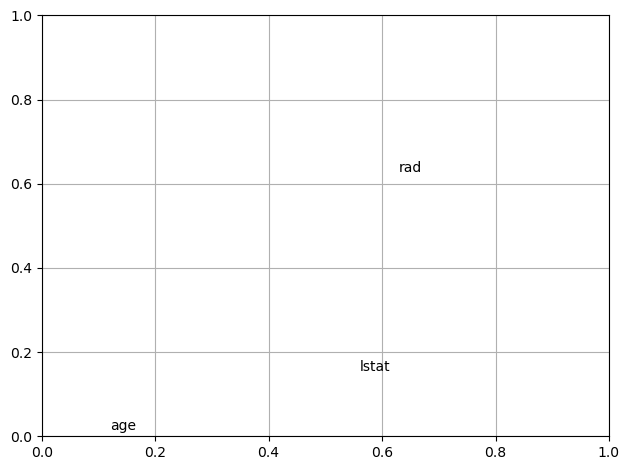

In [29]:
# Annotate each point with the predictor name
for i, predictor in enumerate(predictors):
    plt.annotate(predictor, (comparison_data['simple_regression_coefficient'][predictor], comparison_data['multiple_regression_coefficient'][predictor]), textcoords="offset points", xytext=(5,5), ha='left')

plt.axhline(y=0, color='r', linestyle='--', alpha=0.5) #Add horizontal line
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5) #Add vertical line
plt.grid(True) # Add grid
plt.tight_layout()
plt.show()

*位於此象限的預測變數在簡單和多元迴歸模型中都對 crim 產生正向影響。
'rad': Index of accessibility to radial highways. (徑向高速公路可達性指數)
'lstat': Percentage of lower status of the population. (人口中弱勢群體的百分比)
'age': Proportion of owner-occupied units built prior to 1940. (1940 年之前建造的自有住宅比例)

(d) Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form
The polynomial regression equation is: Y = β_0 + β_1X + β_2X^2 + β_3X^3 + ε

In [35]:
# Define the response variable
response = 'crim'

# Get the list of predictors
predictors = Boston.columns.tolist()
predictors.remove(response)

# Loop through each predictor and fit a cubic regression model
results = {}
for predictor in predictors:
    # Fit the cubic regression model
    formula = f'{response} ~ {predictor} + I({predictor}**2) + I({predictor}**3)'
    model = sm.ols(formula, data=Boston).fit()

    # Store the results
    results[predictor] = {
        'p_value_linear': model.pvalues[predictor],
        'p_value_quadratic': model.pvalues[f'I({predictor} ** 2)'],
        'p_value_cubic': model.pvalues[f'I({predictor} ** 3)']
    }

    # Print the results
    print(f"Predictor: {predictor}")
    print(f"  P-value (Linear): {results[predictor]['p_value_linear']:.4f}")
    print(f"  P-value (Quadratic): {results[predictor]['p_value_quadratic']:.4f}")
    print(f"  P-value (Cubic): {results[predictor]['p_value_cubic']:.4f}")
    print("-" * 30)

# Identify predictors with evidence of non-linear association (p < 0.05 for quadratic or cubic term)
alpha = 0.05  # Significance level
nonlinear_predictors = [p for p, r in results.items() if r['p_value_quadratic'] < alpha or r['p_value_cubic'] < alpha]

print("\nPredictors with Evidence of Non-Linear Association (p < {} for quadratic or cubic term):".format(alpha))
for predictor in nonlinear_predictors:
    print(f"- {predictor}")

Predictor: zn
  P-value (Linear): 0.0026
  P-value (Quadratic): 0.0938
  P-value (Cubic): 0.2295
------------------------------
Predictor: indus
  P-value (Linear): 0.0001
  P-value (Quadratic): 0.0000
  P-value (Cubic): 0.0000
------------------------------
Predictor: chas
  P-value (Linear): 0.2094
  P-value (Quadratic): 0.2094
  P-value (Cubic): 0.2094
------------------------------
Predictor: nox
  P-value (Linear): 0.0000
  P-value (Quadratic): 0.0000
  P-value (Cubic): 0.0000
------------------------------
Predictor: rm
  P-value (Linear): 0.2118
  P-value (Quadratic): 0.3641
  P-value (Cubic): 0.5086
------------------------------
Predictor: age
  P-value (Linear): 0.1427
  P-value (Quadratic): 0.0474
  P-value (Cubic): 0.0067
------------------------------
Predictor: dis
  P-value (Linear): 0.0000
  P-value (Quadratic): 0.0000
  P-value (Cubic): 0.0000
------------------------------
Predictor: rad
  P-value (Linear): 0.6234
  P-value (Quadratic): 0.6130
  P-value (Cubic): 0.482

結論：
根據以上分析，indus、nox、age、dis、ptratio 和 medv 這些預測變數與犯罪率之間存在非線性關係的證據，這表示它們對犯罪率的影響可能無法用簡單的直線來描述，
需要使用更複雜的模型來捕捉它們之間的關係。

建議：
對於具有非線性關係的預測變數，可以嘗試使用更高階的多項式迴歸、樣條迴歸或其他非線性模型來更好地擬合數據。